# Importe de librerias

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   

import warnings
warnings.filterwarnings('ignore')

In [106]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohankrishnathalla/global-ai-and-data-jobs-salary-dataset")

# Exploracion del dataset

In [107]:
df = pd.read_csv(f"{path}/global_ai_jobs.csv")  

In [108]:
df.shape

(90000, 35)

In [109]:
df_2part = df[df["year"] >= 2023].copy()

In [110]:
df_2part.shape

(51387, 35)

In [111]:
df_2part.isnull().sum()

id                         0
country                    0
job_role                   0
ai_specialization          0
experience_level           0
experience_years           0
salary_usd                 0
bonus_usd                  0
education_required         0
industry                   0
company_size               0
interview_rounds           0
year                       0
work_mode                  0
weekly_hours               0
company_rating             0
job_openings               0
hiring_difficulty_score    0
layoff_risk                0
ai_adoption_score          0
company_funding_billion    0
economic_index             0
ai_maturity_years          0
offer_acceptance_rate      0
tax_rate_percent           0
vacation_days              0
skill_demand_score         0
automation_risk            0
job_security_score         0
career_growth_score        0
work_life_balance_score    0
promotion_speed            0
salary_percentile          0
cost_of_living_index       0
employee_satis

In [112]:
df_2part.duplicated().sum()

np.int64(0)

Analizamos el dataset y vemos que no contamos con nulos ni con datos duplicados asi que procedemos a la seleccion de atributos relevantes, haciendo una copia del original.

In [113]:
df_2part.drop(columns=["id","bonus_usd", "industry", "interview_rounds", "job_openings", "company_rating", "hiring_difficulty_score", "economic_index", "layoff_risk","ai_maturity_years", "offer_acceptance_rate", "tax_rate_percent", "cost_of_living_index", "salary_percentile", "vacation_days", "job_security_score", "career_growth_score", "work_life_balance_score", "company_funding_billion", "promotion_speed", "skill_demand_score", "automation_risk"], inplace=True)

In [114]:
df_2part.shape

(51387, 13)

In [115]:
df_2part.info()

<class 'pandas.DataFrame'>
Index: 51387 entries, 3 to 89999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                51387 non-null  str    
 1   job_role               51387 non-null  str    
 2   ai_specialization      51387 non-null  str    
 3   experience_level       51387 non-null  str    
 4   experience_years       51387 non-null  int64  
 5   salary_usd             51387 non-null  int64  
 6   education_required     51387 non-null  str    
 7   company_size           51387 non-null  str    
 8   year                   51387 non-null  int64  
 9   work_mode              51387 non-null  str    
 10  weekly_hours           51387 non-null  float64
 11  ai_adoption_score      51387 non-null  int64  
 12  employee_satisfaction  51387 non-null  int64  
dtypes: float64(1), int64(5), str(7)
memory usage: 8.3 MB


Despues de haber analizado cada uno de los atributos hemos decidido utilizar los mostrados anteriormente, reduciendo el dataset de 35 atributos a los 13 mas relevantes para nuestro objetivo.

In [116]:
df_2part.head()

,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,education_required,company_size,year,work_mode,weekly_hours,ai_adoption_score,employee_satisfaction
3,India,Software Engineer AI,Computer Vision,Senior,6,43268,Diploma,Large,2026,Onsite,52.2,74,56
8,Australia,NLP Engineer,Forecasting,Senior,10,153176,Bachelor,Small,2024,Remote,52.9,54,85
9,Brazil,Machine Learning Engineer,Forecasting,Lead,19,102716,Bootcamp,Enterprise,2023,Onsite,40.8,77,83
10,France,Software Engineer AI,NLP,Entry,1,62612,Diploma,Large,2026,Onsite,46.5,76,61
12,Netherlands,AI Engineer,Reinforcement Learning,Entry,1,81093,Bachelor,Medium,2023,Onsite,38.6,66,71


# Analisis univariante

### Variables categoricas

las cuales son `country`, `job_role`, `ai_specialization`, `experience_level`, `education_required`, `company_size`, `work_mode`

In [117]:
print(df_2part["country"].value_counts())
print(df_2part["job_role"].value_counts())
print(df_2part["ai_specialization"].value_counts())
print(df_2part["experience_level"].value_counts())
print(df_2part["education_required"].value_counts())
print(df_2part["company_size"].value_counts())
print(df_2part["work_mode"].value_counts())

country
Brazil         4385
Australia      4346
Germany        4333
UAE            4321
UK             4305
Netherlands    4296
Canada         4280
India          4272
Singapore      4269
USA            4244
France         4226
Japan          4110
Name: count, dtype: int64
job_role
NLP Engineer                 6588
AI Engineer                  6464
Machine Learning Engineer    6436
Software Engineer AI         6428
Computer Vision Engineer     6409
Data Scientist               6390
Research Scientist           6365
Data Analyst                 6307
Name: count, dtype: int64
ai_specialization
LLM                       6585
Computer Vision           6518
MLOps                     6433
NLP                       6412
Reinforcement Learning    6400
Analytics                 6379
Generative AI             6355
Forecasting               6305
Name: count, dtype: int64
experience_level
Senior    12974
Lead      12936
Mid       12779
Entry     12698
Name: count, dtype: int64
education_required
B

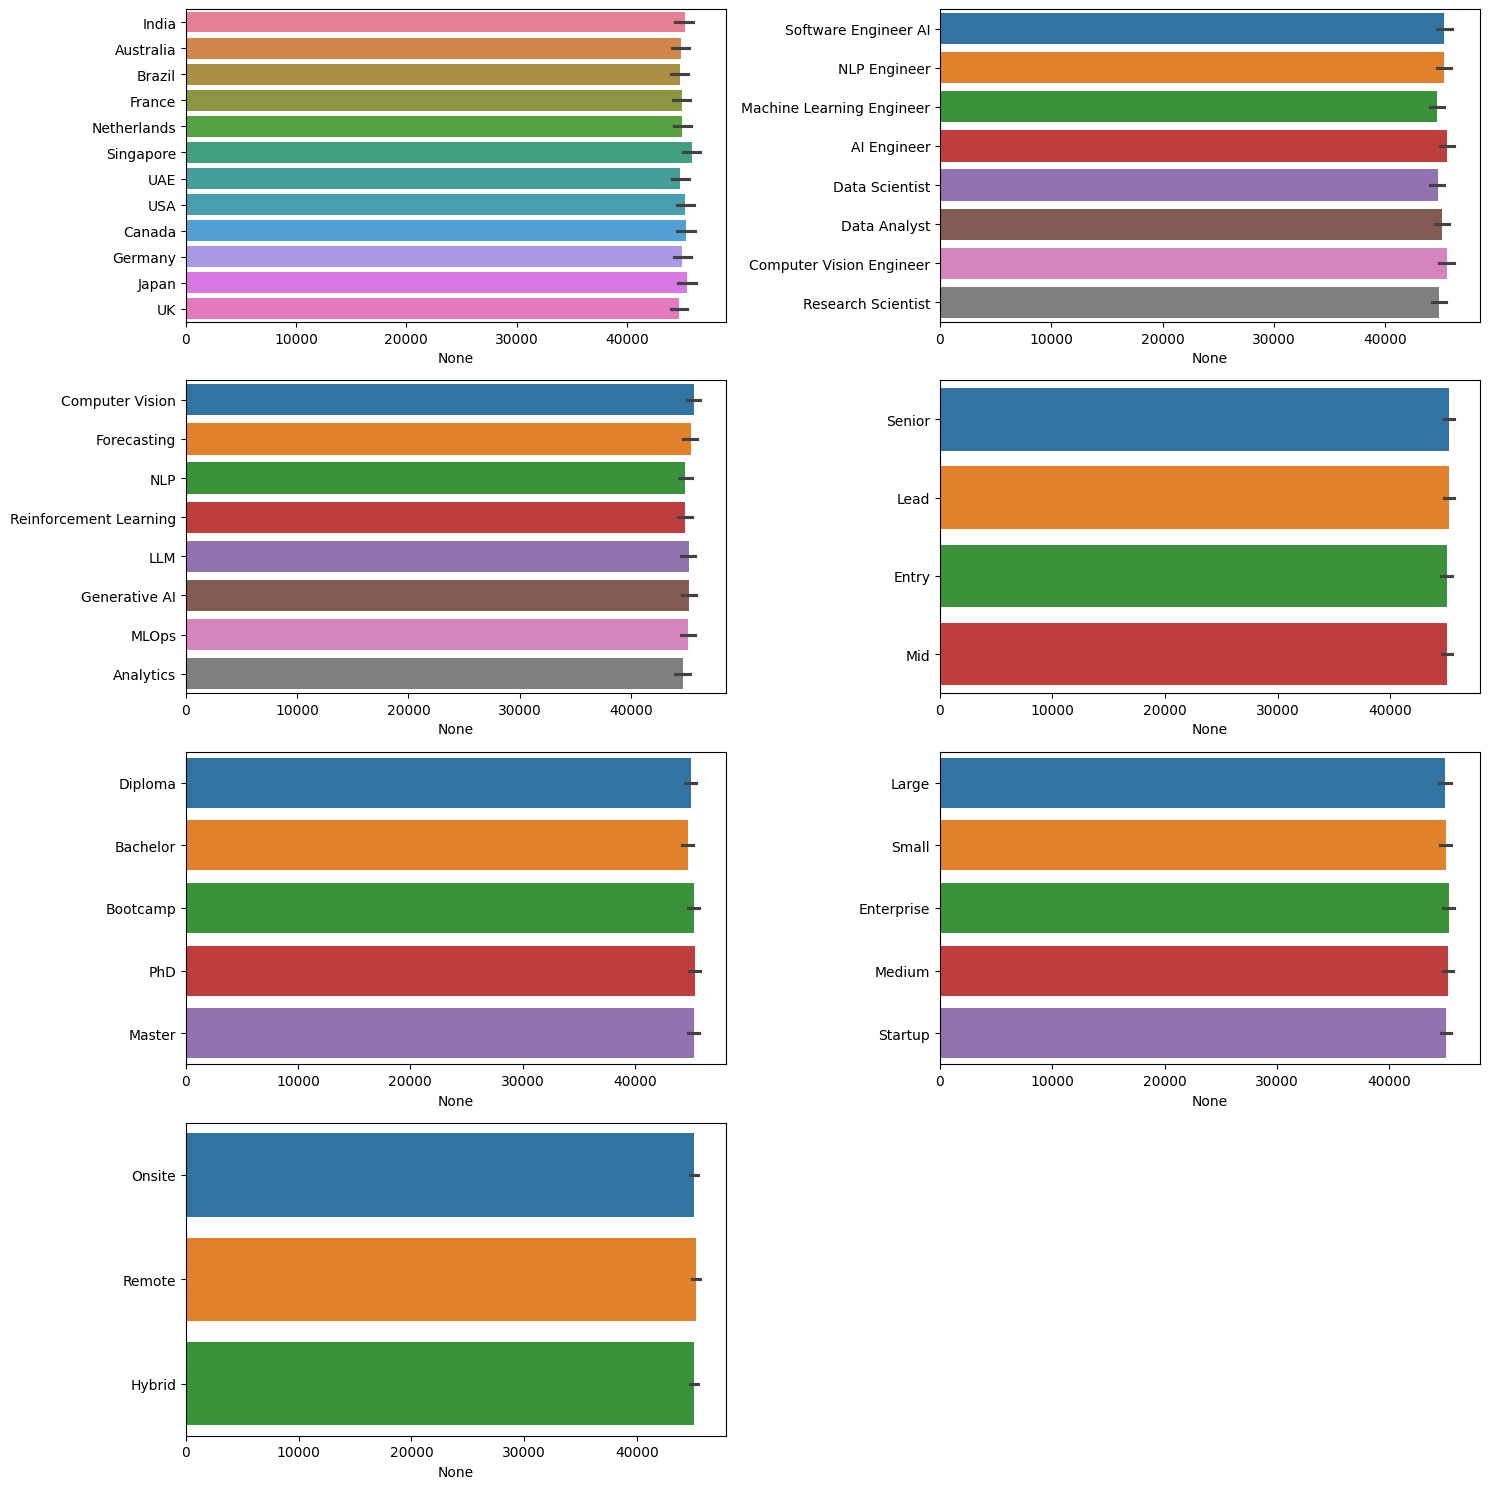

In [118]:
var_cat = ["country","job_role", "ai_specialization", "experience_level", "education_required", "company_size", "work_mode"]

fig, axis = plt.subplots(4, 2, figsize=(15, 15))

sns.barplot(ax =axis[0][0], data=df_2part, y=df_2part["country"].values, x=df_2part["country"].index,  hue=df_2part["country"].values)
sns.barplot(ax =axis[0][1], data=df_2part, y=df_2part["job_role"].values, x=df_2part["job_role"].index, hue=df_2part["job_role"].values)
sns.barplot(ax =axis[1][0], data=df_2part, y=df_2part["ai_specialization"].values, x=df_2part["ai_specialization"].index, hue=df_2part["ai_specialization"].values)
sns.barplot(ax =axis[1][1], data=df_2part, y=df_2part["experience_level"].values, x=df_2part["experience_level"].index, hue=df_2part["experience_level"].values)
sns.barplot(ax =axis[2][0], data=df_2part, y=df_2part["education_required"].values, x=df_2part["education_required"].index, hue=df_2part["education_required"].values)
sns.barplot(ax =axis[2][1], data=df_2part, y=df_2part["company_size"].values, x=df_2part["company_size"].index, hue=df_2part["company_size"].values)
sns.barplot(ax =axis[3][0], data=df_2part, y=df_2part["work_mode"].values, x=df_2part["work_mode"].index, hue=df_2part["work_mode"].values)

fig.delaxes(axis[3][1])

plt.tight_layout()
plt.show()

### Observaciones

- En todas las graficas podemos observar que tenemos casi las mismas cantidades en cada uno de los valores.
- 

## Variables numericas

In [119]:
df_2part.head()

,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,education_required,company_size,year,work_mode,weekly_hours,ai_adoption_score,employee_satisfaction
3,India,Software Engineer AI,Computer Vision,Senior,6,43268,Diploma,Large,2026,Onsite,52.2,74,56
8,Australia,NLP Engineer,Forecasting,Senior,10,153176,Bachelor,Small,2024,Remote,52.9,54,85
9,Brazil,Machine Learning Engineer,Forecasting,Lead,19,102716,Bootcamp,Enterprise,2023,Onsite,40.8,77,83
10,France,Software Engineer AI,NLP,Entry,1,62612,Diploma,Large,2026,Onsite,46.5,76,61
12,Netherlands,AI Engineer,Reinforcement Learning,Entry,1,81093,Bachelor,Medium,2023,Onsite,38.6,66,71


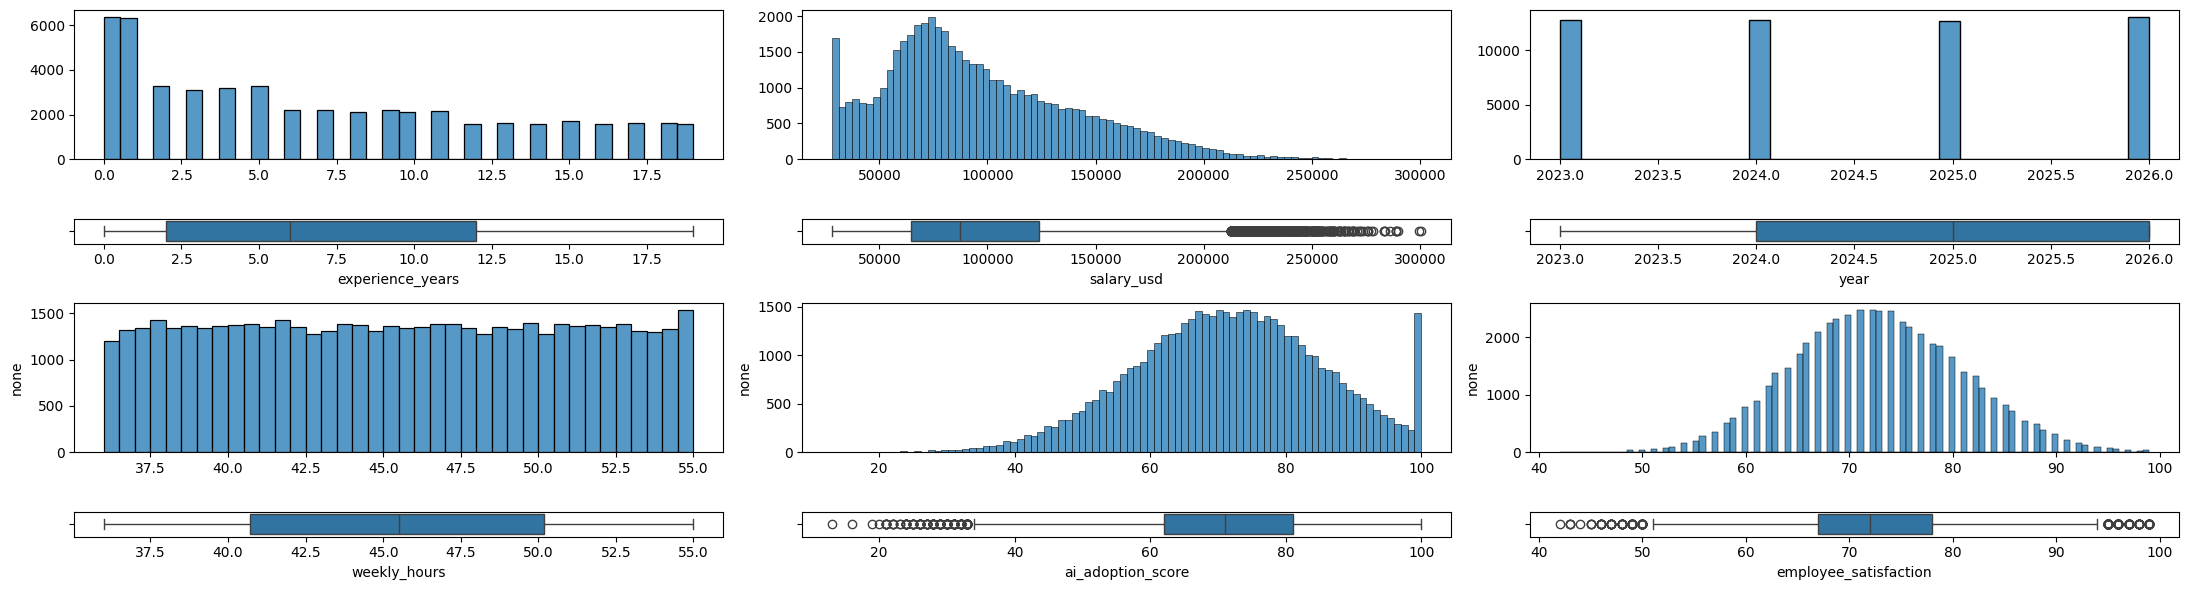

In [120]:
var_num = ['experience_years', 'salary_usd','year', 'weekly_hours', 'ai_adoption_score', 'employee_satisfaction']

fig, axis = plt.subplots(4, 3, figsize=(22, 6), gridspec_kw={'height_ratios': [6, 1, 6, 1]})

for i, var in enumerate(var_num):
    if  i < 3:
        sns.histplot(ax=axis[0, i], data=df_2part, x=var).set(xlabel=None)
        sns.boxplot(ax=axis[1, i], data=df_2part, x=var)
        axis[0, i].set(ylabel=None)
    elif i >= 3 and i < 6:
        col_idx = i - 3
        sns.histplot(ax=axis[2, col_idx], data=df_2part, x=var).set(xlabel=None)
        sns.boxplot(ax=axis[3, col_idx], data=df_2part, x=var)
        axis[2, col_idx].set(ylabel="none")


plt.tight_layout()
plt.show()

### Observaciones

- Con respecto a `experience_year` observamos que hay bastante cantidad entre lkos 0 - 2.5 años  y luego va disminuyendo poco a poco hasta los 18 años aprox. de experiencia.
- `Salary_usd` esta bastante bien distribuido entre los 50k y los 120k anuales.
- `Year` es una variable categorica numerica y esta bien distribuida.
- `weekly_hours` esta bastante variado entre las cantidades de horas trabajadas a la semana, mas adelante veremos como afecta a nivel sueldo anual.
- `ai_adoption_score`, se puede observasr claramente que la mayoria esta entre un 60 - 80% de uso y adopcion de inteligencia artificial, teniendo tambien un parte considerable que es 100%.
- Se puede observar que la satisfaccion de los empleados ronda entre el 65% y casi el 80%, teniando algunos pocos de mas de eso y menos.